# Práctica 2: Estadística Descriptiva y Modelado de Entidades

## Objetivo
Realizar un análisis estadístico descriptivo del dataset de tiros de la EPL 2024-2025. Identificar las entidades principales y sus relaciones, diagramarlas, y obtener estadísticas agrupadas por estas entidades.

## Requisitos
- Ejecutar estadísticas descriptivas.
- Identificar entidades y relaciones.
- Dibujar el diagrama de entidades.
- Agrupar datos por entidades y obtener estadísticas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
%matplotlib inline
sns.set(style="whitegrid")

## 1. Carga de Datos
Utilizamos el dataset limpio generado en la Práctica 1.

In [2]:
try:
    df = pd.read_csv('cleaned_epl_shots.csv')
    # Convertir fecha a datetime nuevamente ya que CSV pierde el tipo
    df['match_date'] = pd.to_datetime(df['match_date'])
    print("Dataset cargado exitosamente.")
except FileNotFoundError:
    print("El archivo no se encuentra. Verifica la ruta.")

df.head()

Dataset cargado exitosamente.


,isHome,shotType,situation,bodyPart,goalMouthLocation,goalMouthCoordinates,blockCoordinates,xg,xgot,id,...,periodTimeSeconds,incidentType,goalType,match_id,match_date,player_name,player_position,player_id,shot_x,shot_y
0,False,block,assisted,left-foot,low-centre,"{""x"": 0, ""y"": 50.1, ""z"": 19}","{""x"": 16.7, ""y"": 39.5, ""z"": 0}",0.044247,0.0,3701430,...,18,shot,NaN,12436910,2024-09-01,Jean-Philippe Mateta,F,848276,19.8,37.6
1,True,block,assisted,right-foot,low-centre,"{""x"": 0, ""y"": 49.5, ""z"": 19}","{""x"": 0.90000000000001, ""y"": 51.6, ""z"": 0}",0.137589,0.0,4475948,...,24,shot,NaN,12436629,2025-02-22,Jaden Philogene-Bidace,M,1014461,7.6,60.1
2,True,block,throw-in-set-piece,left-foot,low-centre,"{""x"": 0, ""y"": 50.7, ""z"": 19}","{""x"": 12.4, ""y"": 50.2, ""z"": 0}",0.052231,0.0,5000250,...,32,shot,NaN,12436538,2025-05-25,Conor Chaplin,M,784625,14.1,50.3
3,False,block,assisted,right-foot,low-centre,"{""x"": 0, ""y"": 51.4, ""z"": 19}","{""x"": 12, ""y"": 69.3, ""z"": 0}",0.047109,0.0,4742872,...,33,shot,NaN,12436614,2025-04-12,Marcus Rashford,M,814590,14.1,72.9
4,True,block,regular,right-foot,low-centre,"{""x"": 0, ""y"": 48.9, ""z"": 19}","{""x"": 13.7, ""y"": 48.7, ""z"": 0}",0.066052,0.0,4202996,...,33,shot,NaN,12436532,2024-12-29,Eberechi Eze,F,864921,15.1,48.5


## 2. Estadísticas Descriptivas Generales
Analizamos las variables numéricas y categóricas del conjunto de datos completo.

In [3]:
# Resumen estadístico de variables numéricas
print("Estadísticas Numéricas:")
df.describe().T

Estadísticas Numéricas:


,count,mean,min,25%,50%,75%,max,std
xg,7960.0,0.11061,0.002711,0.031062,0.057346,0.122438,0.984898,0.144605
xgot,7963.0,0.111931,0.0,0.0,0.0,0.098909,0.99551,0.228346
id,7987.0,4302716.854138,3605351.0,4034561.0,4218351.0,4590407.0,5006757.0,382337.183904
time,7987.0,49.668586,1.0,27.0,49.0,73.0,90.0,26.612391
addedTime,857.0,3.714119,1.0,2.0,3.0,5.0,13.0,2.297133
timeSeconds,7987.0,2973.167773,10.0,1604.5,2957.0,4325.5,6176.0,1624.974559
reversedPeriodTime,7987.0,20.321648,1.0,8.0,20.0,32.0,45.0,13.75293
reversedPeriodTimeSeconds,7987.0,1319.946037,0.0,665.0,1266.0,2001.0,2698.0,775.288976
periodTimeSeconds,7987.0,1245.735696,1.0,490.0,1219.0,1954.0,2700.0,809.292643
match_id,7987.0,12453309.559785,12436410.0,12436520.0,12436621.0,12436963.0,13854588.0,131423.695981


In [4]:
# Resumen estadístico de variables categóricas (top, freq, unique)
print("Estadísticas Categóricas:")
df.describe(include=['object', 'bool']).T

Estadísticas Categóricas:


,count,unique,top,freq
isHome,7987,2,True,4208
shotType,7987,5,miss,2704
situation,7987,8,assisted,4058
bodyPart,7987,4,right-foot,3868
goalMouthLocation,7987,14,low-centre,2362
goalMouthCoordinates,7987,4601,"{""x"": 0, ""y"": 50.7, ""z"": 19}",63
blockCoordinates,4669,3585,"{""x"": 1.2, ""y"": 50, ""z"": 0}",10
draw,7987,7984,"{""start"": {""x"": 50, ""y"": 11.5}, ""end"": {""x"": 5...",2
incidentType,7987,1,shot,7987
goalType,884,3,regular,801


## 3. Identificación de Entidades y Relaciones

Basado en las columnas del dataset, podemos identificar las siguientes entidades principales:

1.  **Match (Partido):** Identificado por `match_id`. Contiene atributos como `match_date`.
2.  **Player (Jugador):** Identificado por `player_id`. Contiene atributos como `player_name`, `player_position`.
3.  **Shot (Tiro):** Es la entidad transaccional principal. Cada fila es un tiro. Se relaciona con un *Match* y un *Player*.

### Diagrama de Entidad-Relación (ERD)

```mermaid
erDiagram
    MATCH ||--|{ SHOT : contains
    PLAYER ||--|{ SHOT : executes
    
    MATCH {
        int match_id PK
        date match_date
    }
    
    PLAYER {
        int player_id PK
        string player_name
        string player_position
    }
    
    SHOT {
        int id PK
        float xg
        float xgot
        string shotType
        string result
        int time
        int match_id FK
        int player_id FK
    }
```

## 4. Estadísticas Agrupadas por Entidades

### 4.1. Análisis por Jugador (Player)
Agrupamos los datos por jugador para obtener métricas de rendimiento acumuladas.

In [5]:
# Agrupación por jugador
player_stats = df.groupby(['player_name', 'player_position']).agg(
    total_shots=('id', 'count'),
    avg_xg=('xg', 'mean'),
    total_xg=('xg', 'sum'),
    max_xgot=('xgot', 'max')
).reset_index()

# Top 10 jugadores con más tiros
top_shooters = player_stats.sort_values(by='total_shots', ascending=False).head(10)
top_shooters

,player_name,player_position,total_shots,avg_xg,total_xg,max_xgot
27,Antoine Semenyo,M,106,0.080906,8.576073,0.765100
76,Cole Palmer,M,99,0.120032,11.883206,0.927057
123,Erling Haaland,F,92,0.217741,20.032158,0.993488
307,Mohamed Salah,M,92,0.200461,18.442437,0.985187
285,Matheus Cunha,F,85,0.073893,6.280906,0.706593
111,Eberechi Eze,F,84,0.099382,8.348047,0.995255
439,Yoane Wissa,F,81,0.183817,14.889197,0.994600
15,Alexander Isak,F,79,0.195664,15.457446,0.995388
336,Ollie Watkins,F,78,0.185177,14.443822,0.995191
190,Jarrod Bowen,M,76,0.095757,7.277548,0.970389


/var/folders/m7/y719fmdd247b72m0_t2221q40000gn/T/ipykernel_73128/3071321025.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=player_stats.sort_values(by='total_xg', ascending=False).head(10), x='total_xg', y='player_name', palette='viridis')


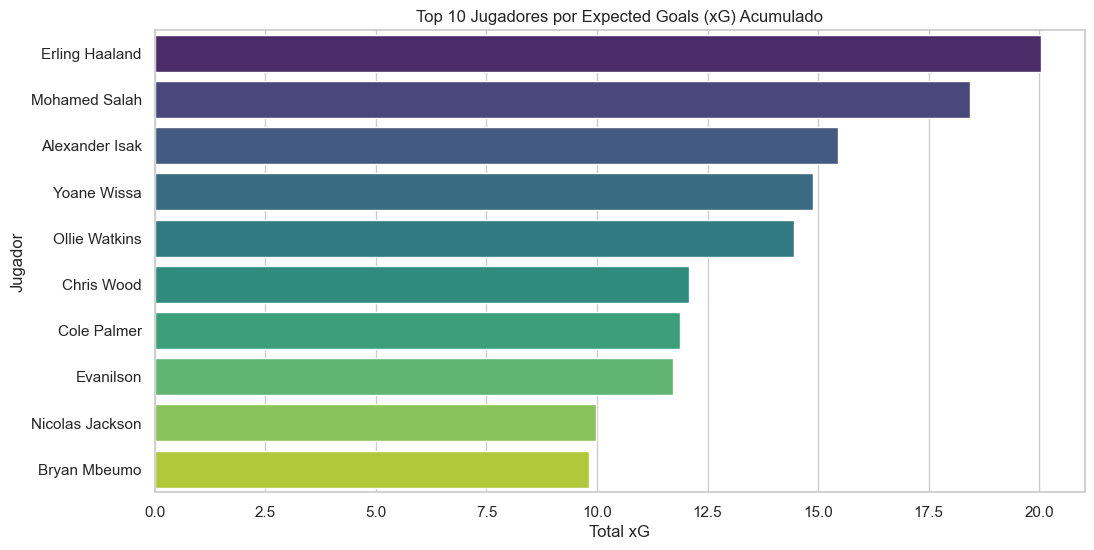

In [6]:
# Visualización: Top 10 jugadores por xG total
plt.figure(figsize=(12, 6))
sns.barplot(data=player_stats.sort_values(by='total_xg', ascending=False).head(10), x='total_xg', y='player_name', palette='viridis')
plt.title('Top 10 Jugadores por Expected Goals (xG) Acumulado')
plt.xlabel('Total xG')
plt.ylabel('Jugador')
plt.show()

### 4.2. Análisis por Partido (Match)
Agrupamos por partido para ver la intensidad ofensiva en cada encuentro.

In [7]:
# Agrupación por partido
match_stats = df.groupby('match_id').agg(
    shots_in_match=('id', 'count'),
    total_match_xg=('xg', 'sum'),
    match_date=('match_date', 'first')
).reset_index()

# Estadísticas de los partidos
match_stats.describe()

,match_id,shots_in_match,total_match_xg,match_date
count,3.080000e+02,308.000000,308.000000,308
mean,1.245647e+07,25.931818,2.858615,2025-01-12 12:42:04.675324672
min,1.243641e+07,13.000000,0.925559,2024-08-17 00:00:00
25%,1.243652e+07,22.000000,2.185912,2024-11-19 18:00:00
50%,1.243662e+07,26.000000,2.738125,2025-01-04 12:00:00
75%,1.243696e+07,29.000000,3.446500,2025-03-16 00:00:00
max,1.385459e+07,48.000000,5.728031,2025-05-25 00:00:00
std,1.447806e+05,6.063606,0.956786,NaN


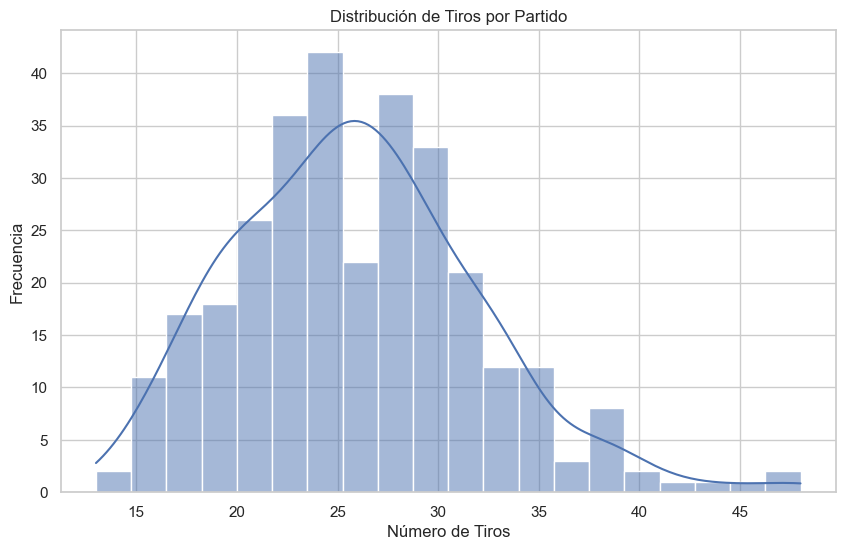

In [8]:
# Distribución de tiros por partido
plt.figure(figsize=(10, 6))
sns.histplot(match_stats['shots_in_match'], bins=20, kde=True)
plt.title('Distribución de Tiros por Partido')
plt.xlabel('Número de Tiros')
plt.ylabel('Frecuencia')
plt.show()

### 4.3. Análisis por Tipo de Tiro (Shot Type)
Evaluamos la calidad de las oportunidades según el tipo de situación.

In [9]:
# Agrupación por situación de juego
situation_stats = df.groupby('situation').agg(
    count=('id', 'count'),
    avg_xg=('xg', 'mean')
).sort_values(by='avg_xg', ascending=False)

situation_stats

,count,avg_xg
situation,,
penalty,67,0.788400
fast-break,565,0.163699
regular,1077,0.106484
assisted,4058,0.105040
throw-in-set-piece,183,0.102870
set-piece,492,0.093770
corner,1322,0.089150
free-kick,223,0.063130


## Conclusiones Preliminares
- Se han identificado las entidades clave: Jugadores y Partidos.
- La agrupación de datos permite ver claramente quiénes son los jugadores más ofensivos y qué partidos tuvieron más acción.
- El diagrama ER muestra cómo los tiros conectan a jugadores con partidos.